# 4.1.1 Caracterização Geográfica das Áreas Abastecidas

## Análise da Distribuição de Água por Prestador e Região — Minas Gerais

**Objetivo:** Identificar quais prestadores de serviço atendem quais municípios/regiões de MG,
analisar a cobertura de abastecimento de água e as perdas na distribuição.

**Limitação dos dados SNIS:** Os dados disponíveis são em nível **municipal** — não há
informação sub-municipal (bairros, zonas de pressão, pontas de rede, reservatórios).
Portanto, não é possível construir uma "planta de distribuição" interna ao município.
O que se pode fazer é mapear **qual prestador atende qual município/mesorregião**.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import geopandas as gpd
import warnings
warnings.filterwarnings('ignore')

# ── Carrega dados SNIS (Mun_Final) ───────────────────────────────────────
df_mun = pd.read_csv(
    'Mun_Final.csv', sep=';', encoding='utf-16', decimal=',',
    thousands='.', index_col=False
)
df_mun['Ano de Referência'] = df_mun['Ano de Referência'].astype(int)
df_mun['Código do IBGE'] = df_mun['Código do IBGE'].astype('Int64')
df_mun['Código do IBGE'] = (
    df_mun.groupby('Código do Município')['Código do IBGE']
    .transform(lambda x: x.ffill().bfill())
)

# Filtra MG e ano 2022
df_mg = df_mun[df_mun['Estado'] == 'MG'].copy()
df = df_mg[df_mg['Ano de Referência'] == 2022].copy()
print(f'Municípios MG em 2022: {df.shape[0]}')
df.head(3)

Municípios MG em 2022: 853


,Código do IBGE,Código do Município,Município,Estado,Ano de Referência,Prestadores,Serviços,Natureza Jurídica,POP_TOT - População total do município (Fonte: IBGE):,POP_URB - População urbana do município (Fonte: IBGE),...,IN015_RS - Taxa de cobertura regular do serviço de coleta de rdo em relação à população total do município,IN018_RS - Produtividade média dos empregados na coleta (coletadores + motoristas) na coleta (rdo + rpu) em relação à massa coletada,IN019_RS - Taxa de empregados (coletadores + motoristas) na coleta (rdo + rpu) em relação à população urbana,IN028_RS - Massa de resíduos domiciliares e públicos (rdo+rpu) coletada per capita em relação à população total atendida pelo serviço de coleta,IN030_RS - Taxa de cobertura do serviço de coleta seletiva porta-a-porta em relação à população urbana do município.,IN031_RS - Taxa de recuperação de materiais recicláveis (exceto matéria orgânica e rejeitos) em relação à quantidade total (rdo + rpu) coletada,IN044_RS - Produtividade média dos varredores (prefeitura + empresas contratadas),IN045_RS - Taxa de varredores em relação à população urbana,IN048_RS - Extensão total anual varrida per capita,IN051_RS - Taxa de capinadores em relação à população urbana
0,3100104,310010,Abadia dos Dourados,MG,2022,[31062000] Companhia de Saneamento de Minas Ge...,Água | Res. Sólidos,Sociedade de economia mista com administração ...,6272,NaN,...,93.27,NaN,NaN,0.18,NaN,22.22,NaN,NaN,NaN,NaN
6,3100203,310020,Abaeté,MG,2022,[31062000] Companhia de Saneamento de Minas Ge...,Água e Esgoto | Res. Sólidos,Sociedade de economia mista com administração ...,22675,NaN,...,86.14,2102.77,NaN,1.11,NaN,NaN,NaN,NaN,NaN,NaN
12,3100302,310030,Abre Campo,MG,2022,[31003011] Serviço Autônomo de Água e Esgoto -...,Água e Esgoto | Res. Sólidos,Autarquia | Administração pública direta,13927,NaN,...,93.34,NaN,NaN,0.32,NaN,33.33,NaN,NaN,NaN,NaN


## 1. Prestadores de Serviço de Água em MG

Quais são os principais prestadores e quantos municípios cada um atende?

In [9]:
# ── Extrai o prestador principal de cada município ──────────────────────
# A coluna 'Prestadores' pode ter múltiplos prestadores separados por ' | '
# Vamos criar uma coluna com o primeiro prestador e outra expandida

def extrair_nome_prestador(texto):
    """Extrai nome curto do prestador a partir do formato '[cod] Nome - SIGLA'"""
    if pd.isna(texto):
        return 'Sem informação'
    # Pega todos os prestadores
    partes = str(texto).split(' | ')
    nomes = []
    for p in partes:
        # Remove código entre colchetes
        if ']' in p:
            p = p.split('] ', 1)[-1]
        # Pega a sigla se existir (após ' - ')
        if ' - ' in p:
            sigla = p.split(' - ')[-1].strip()
            nomes.append(sigla)
        else:
            nomes.append(p.strip())
    return ' | '.join(nomes)

def prestador_agua(row):
    """Identifica o prestador responsável pelo serviço de ÁGUA"""
    servicos = str(row.get('Serviços', ''))
    prestadores = str(row.get('Prestadores', ''))
    if pd.isna(row.get('Prestadores')):
        return 'Sem informação'
    
    lista_serv = [s.strip() for s in servicos.split(' | ')]
    lista_prest = [p.strip() for p in prestadores.split(' | ')]
    
    for s, p in zip(lista_serv, lista_prest):
        if 'gua' in s:  # 'Água' ou 'Água e Esgoto'
            if ']' in p:
                p = p.split('] ', 1)[-1]
            if ' - ' in p:
                return p.split(' - ')[-1].strip()
            return p.strip()
    # Se não encontrar, retorna o primeiro
    return extrair_nome_prestador(row['Prestadores']).split(' | ')[0]

df['Prestador_Agua'] = df.apply(prestador_agua, axis=1)

# ── Contagem de municípios por prestador ──────────────────────────────────
contagem_prest = df['Prestador_Agua'].value_counts()
print('=== Top 15 Prestadores de Água em MG (nº de municípios) ===\n')
print(contagem_prest.head(15).to_string())
print(f'\nTotal de prestadores distintos: {contagem_prest.shape[0]}')

=== Top 15 Prestadores de Água em MG (nº de municípios) ===

Prestador_Agua
COPASA     325
SAAE        63
COPANOR     50
PMC         30
PMP         24
PMA         17
PMI         17
PMM         14
PMG         10
PMJ         10
PMB          8
PMD          8
PMT          8
PMS          7
PMCA         6

Total de prestadores distintos: 203


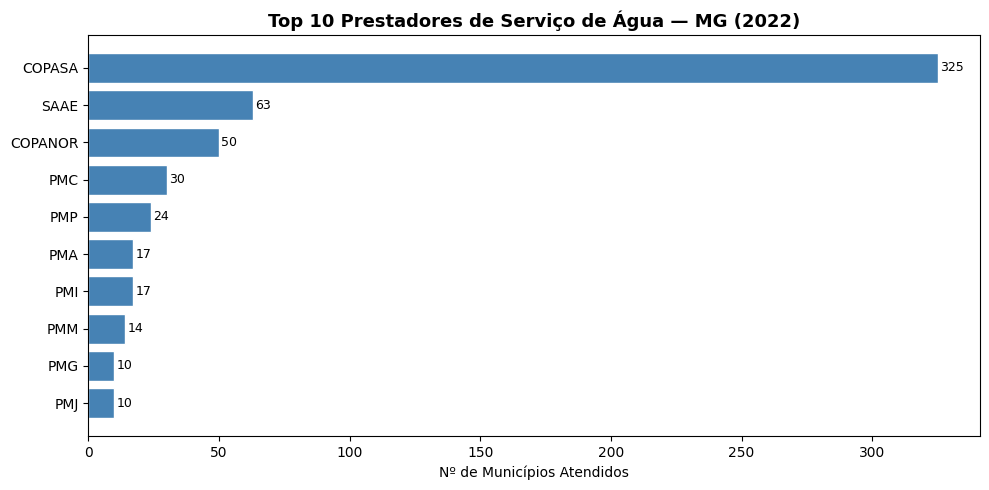

In [10]:
# ── Gráfico: Top 10 prestadores por nº de municípios atendidos ──────────
top10 = contagem_prest.head(10)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top10.index[::-1], top10.values[::-1], color='steelblue', edgecolor='white')
ax.set_xlabel('Nº de Municípios Atendidos')
ax.set_title('Top 10 Prestadores de Serviço de Água — MG (2022)', fontsize=13, fontweight='bold')
for bar in bars:
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width())}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 2. Cobertura de Abastecimento de Água (IN055_AE)

Índice de atendimento total de água — qual a % da população atendida em cada município?

In [11]:
col_cobertura = 'IN055_AE - Índice de atendimento total de água'
col_perdas = 'IN049_AE - Índice de perdas na distribuição'

# ── Estatísticas descritivas ──────────────────────────────────────────────
print('=== Cobertura de Água (IN055_AE) — Estatísticas ===\n')
print(df[col_cobertura].describe().round(2).to_string())

# Municípios com cobertura < 50%
baixa_cob = df[df[col_cobertura] < 50][['Município', col_cobertura, 'Prestador_Agua',
                                          'POP_TOT - População total do município (Fonte: IBGE):']]
baixa_cob = baixa_cob.sort_values(col_cobertura)
print(f'\n=== Municípios com cobertura de água < 50% ({baixa_cob.shape[0]} municípios) ===\n')
if baixa_cob.shape[0] > 0:
    print(baixa_cob.head(20).to_string(index=False))
else:
    print('Nenhum município com cobertura abaixo de 50%.')

print(f'\n=== Perdas na Distribuição (IN049_AE) — Estatísticas ===\n')
print(df[col_perdas].describe().round(2).to_string())

=== Cobertura de Água (IN055_AE) — Estatísticas ===

count    836.00
mean      69.78
std       19.67
min       17.49
25%       55.50
50%       71.14
75%       84.98
max      100.00

=== Municípios com cobertura de água < 50% (150 municípios) ===

                Município  IN055_AE - Índice de atendimento total de água Prestador_Agua  POP_TOT - População total do município (Fonte: IBGE):
     São João das Missões                                           17.49         COPASA                                                  13024
                Cuparaque                                           19.56            PMC                                                   3983
          Bonito de Minas                                           22.20         COPASA                                                  10204
  Santo Antônio do Retiro                                           22.84         COPASA                                                   6629
           Martins Soares        

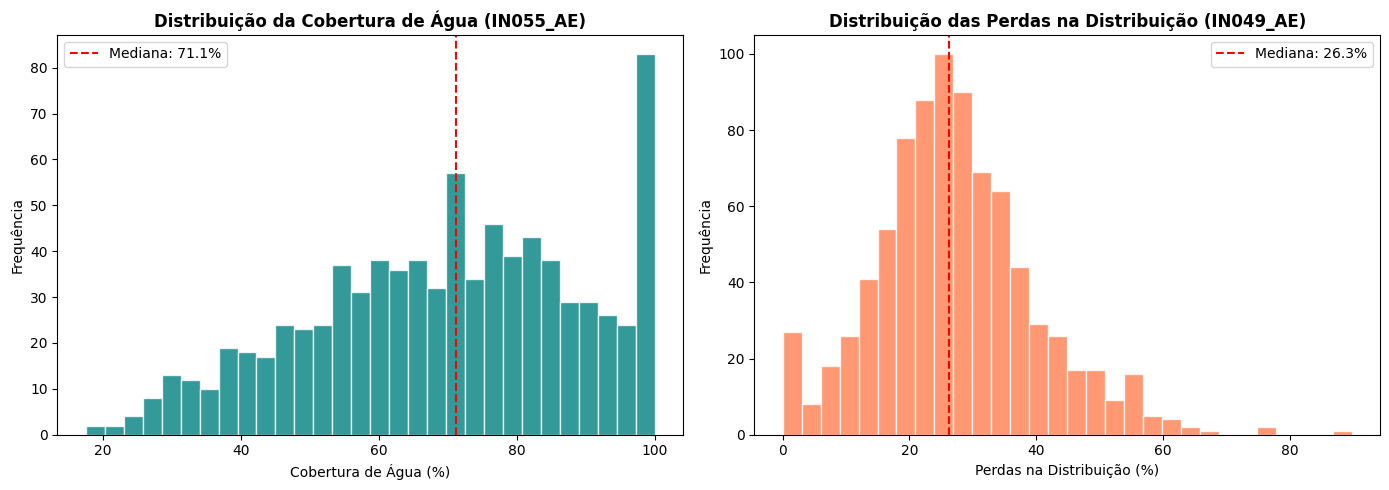

In [12]:
# ── Histograma Cobertura vs Perdas ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df[col_cobertura].dropna(), bins=30, color='teal', edgecolor='white', alpha=0.8)
axes[0].axvline(df[col_cobertura].median(), color='red', ls='--', label=f'Mediana: {df[col_cobertura].median():.1f}%')
axes[0].set_xlabel('Cobertura de Água (%)')
axes[0].set_ylabel('Frequência')
axes[0].set_title('Distribuição da Cobertura de Água (IN055_AE)', fontweight='bold')
axes[0].legend()

axes[1].hist(df[col_perdas].dropna(), bins=30, color='coral', edgecolor='white', alpha=0.8)
axes[1].axvline(df[col_perdas].median(), color='red', ls='--', label=f'Mediana: {df[col_perdas].median():.1f}%')
axes[1].set_xlabel('Perdas na Distribuição (%)')
axes[1].set_ylabel('Frequência')
axes[1].set_title('Distribuição das Perdas na Distribuição (IN049_AE)', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Cobertura e Perdas por Prestador

Comparação de desempenho entre os principais prestadores.

In [13]:
# ── Média de cobertura e perdas por prestador (top 10 por nº municípios) ─
top_prest = contagem_prest.head(10).index.tolist()
df_top = df[df['Prestador_Agua'].isin(top_prest)].copy()

resumo_prest = df_top.groupby('Prestador_Agua').agg(
    n_municipios=('Município', 'count'),
    cobertura_media=(col_cobertura, 'mean'),
    cobertura_mediana=(col_cobertura, 'median'),
    perdas_media=(col_perdas, 'mean'),
    perdas_mediana=(col_perdas, 'median'),
    pop_total=('POP_TOT - População total do município (Fonte: IBGE):', 'sum')
).round(2).sort_values('n_municipios', ascending=False)

print('=== Desempenho dos Top 10 Prestadores ===\n')
resumo_prest

=== Desempenho dos Top 10 Prestadores ===



,n_municipios,cobertura_media,cobertura_mediana,perdas_media,perdas_mediana,pop_total
Prestador_Agua,,,,,,
COPASA,325,66.01,67.86,28.16,26.77,11951743
SAAE,63,88.48,94.89,31.45,32.97,2270515
COPANOR,50,60.59,60.17,33.18,34.22,343333
PMC,30,64.51,68.03,24.57,23.78,258435
PMP,24,71.48,77.81,23.79,23.28,279551
PMA,17,69.58,70.28,30.59,27.04,160143
PMI,17,72.29,70.68,20.32,20.39,145332
PMM,14,67.13,67.70,28.64,26.62,96670
PMG,10,76.22,84.76,22.82,23.11,69728


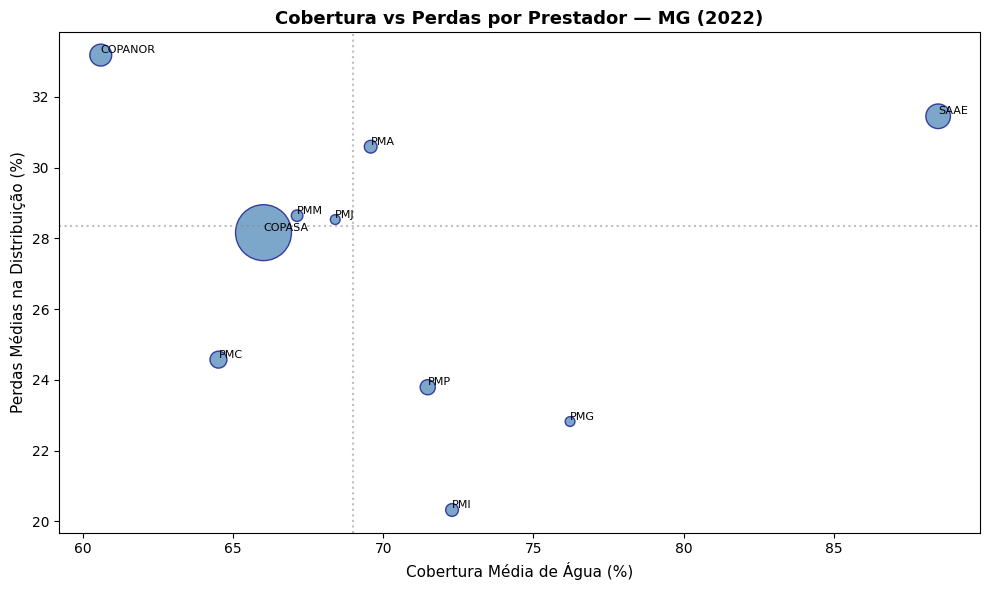

In [14]:
# ── Gráfico comparativo: cobertura média vs perdas médias por prestador ──
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    resumo_prest['cobertura_media'],
    resumo_prest['perdas_media'],
    s=resumo_prest['n_municipios'] * 5,
    alpha=0.7, c='steelblue', edgecolors='navy'
)
for idx, row in resumo_prest.iterrows():
    ax.annotate(idx, (row['cobertura_media'], row['perdas_media']),
                fontsize=8, ha='left', va='bottom')

ax.set_xlabel('Cobertura Média de Água (%)', fontsize=11)
ax.set_ylabel('Perdas Médias na Distribuição (%)', fontsize=11)
ax.set_title('Cobertura vs Perdas por Prestador — MG (2022)',
             fontsize=13, fontweight='bold')
ax.axhline(resumo_prest['perdas_media'].median(), color='gray', ls=':', alpha=0.5)
ax.axvline(resumo_prest['cobertura_media'].median(), color='gray', ls=':', alpha=0.5)
plt.tight_layout()
plt.show()

## 4. Mapa: Qual Prestador Atende Cada Município?

Espacialização do prestador principal de água em cada município de MG.

In [16]:

# ── Carregar geometria de MG ──────────────────────────────────────────────
import geobr
geo = geobr.read_municipality(code_muni='MG', year=2022)
geo = geo.rename(columns={'code_muni': 'id'})
geo['id'] = geo['id'].astype('Int64')
print(f'Geometrias carregadas: {geo.shape[0]} municípios')

# Merge
df['Código do IBGE'] = df['Código do IBGE'].astype('Int64')
geo_merged = geo.merge(df[['Código do IBGE', 'Prestador_Agua', 'Município',
                            col_cobertura, col_perdas]],
                       left_on='id', right_on='Código do IBGE', how='left')

# Classifica: COPASA vs Autarquia/SAAE vs Prefeitura vs Outro
def classificar_prestador(nome):
    if pd.isna(nome) or nome == 'Sem informação':
        return 'Sem dados'
    nome_up = nome.upper()
    if 'COPASA' in nome_up:
        return 'COPASA'
    elif 'COPANOR' in nome_up:
        return 'COPANOR'
    elif any(x in nome_up for x in ['SAAE', 'DMAE', 'DAE', 'CESAMA', 'DEMSUR']):
        return 'Autarquia Municipal'
    elif nome_up.startswith('PM') or 'PREFEITURA' in nome_up:
        return 'Prefeitura'
    else:
        return 'Outro'

geo_merged['Tipo_Prestador'] = geo_merged['Prestador_Agua'].apply(classificar_prestador)
print(geo_merged['Tipo_Prestador'].value_counts())


Geometrias carregadas: 853 municípios
Tipo_Prestador
Prefeitura             375
COPASA                 325
Autarquia Municipal     77
COPANOR                 50
Outro                   20
Sem dados                6
Name: count, dtype: int64


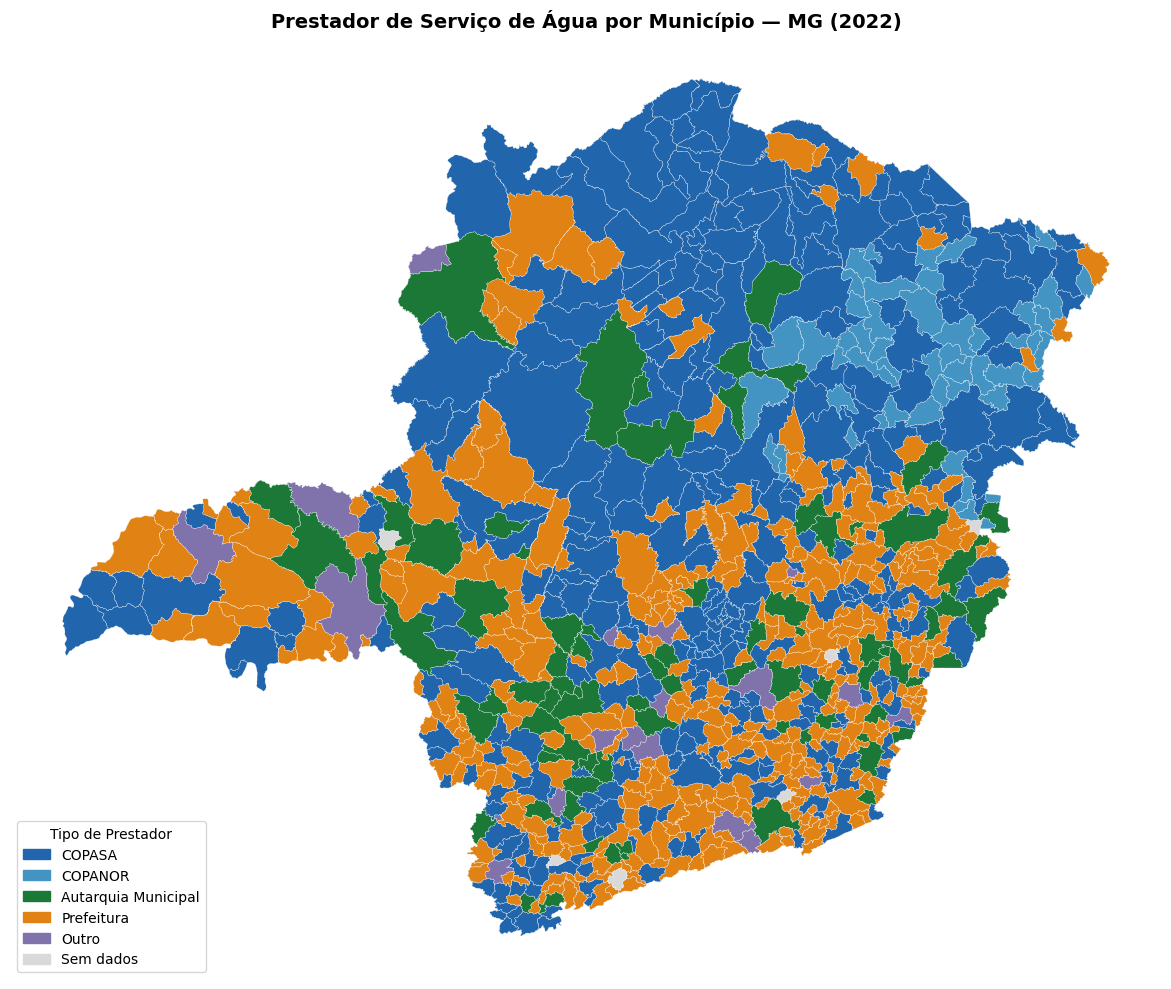

In [23]:

# ── Mapa: Tipo de Prestador por Município ────────────────────────────────
cores_tipo = {
    'COPASA': '#2166ac',
    'COPANOR': '#4393c3',
    'Autarquia Municipal': '#1b7837',
    'Prefeitura': '#e08214',
    'Outro': '#8073ac',
    'Sem dados': '#d9d9d9'
}

fig, ax = plt.subplots(1, 1, figsize=(14, 10))
geo_merged.plot(ax=ax,
                color=geo_merged['Tipo_Prestador'].map(cores_tipo),
                edgecolor='white', linewidth=0.2)

patches = [mpatches.Patch(color=c, label=l) for l, c in cores_tipo.items()
           if l in geo_merged['Tipo_Prestador'].values]
ax.legend(handles=patches, loc='lower left', fontsize=10, title='Tipo de Prestador')
ax.set_title('Prestador de Serviço de Água por Município — MG (2022)',
             fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()


## 5. Mapa: Cobertura de Atendimento de Água (IN055_AE)

Espacialização do índice de atendimento total de água.

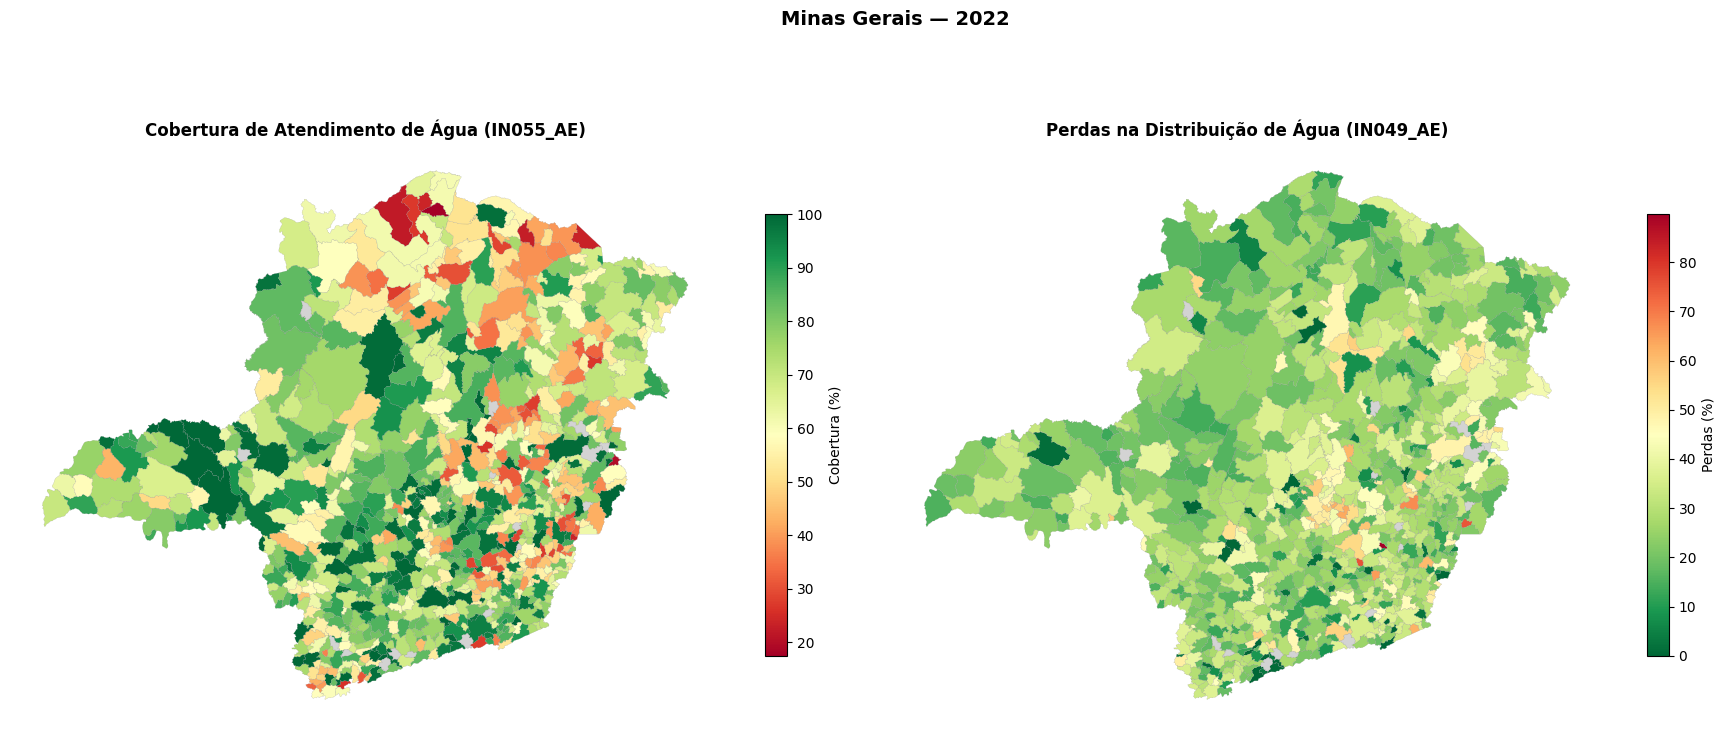

In [24]:
# ── Mapa: Cobertura de Água ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Cobertura
geo_merged.plot(ax=axes[0], column=col_cobertura, cmap='RdYlGn',
                legend=True, edgecolor='gray', linewidth=0.1,
                missing_kwds={'color': 'lightgray', 'label': 'Sem dados'},
                legend_kwds={'shrink': 0.6, 'label': 'Cobertura (%)'})
axes[0].set_title('Cobertura de Atendimento de Água (IN055_AE)',
                  fontsize=12, fontweight='bold')
axes[0].axis('off')

# Perdas
geo_merged.plot(ax=axes[1], column=col_perdas, cmap='RdYlGn_r',
                legend=True, edgecolor='gray', linewidth=0.1,
                missing_kwds={'color': 'lightgray', 'label': 'Sem dados'},
                legend_kwds={'shrink': 0.6, 'label': 'Perdas (%)'})
axes[1].set_title('Perdas na Distribuição de Água (IN049_AE)',
                  fontsize=12, fontweight='bold')
axes[1].axis('off')

plt.suptitle('Minas Gerais — 2022', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 6. Tabela: Prestador × Mesorregião

Cruza o prestador principal com as mesorregiões de MG (via dados pluviais).

In [25]:
# ── Carrega pluviais para obter Mesorregião ──────────────────────────────
df_pluv = pd.read_csv(
    'IndicadoresAguasPluviais-20260423182045.csv', sep=';', encoding='utf-16-le',
    decimal=',', thousands='.', index_col=False
)
df_pluv.rename(columns={'Ano de Refererência': 'Ano de Referência',
                         'Código IBGE': 'Código do IBGE'}, inplace=True)
df_pluv['Código do IBGE'] = df_pluv['Código do IBGE'].astype('Int64')

# Pega mesorregião (última ocorrência por município)
meso = df_pluv[df_pluv['UF'] == 'MG'].drop_duplicates('Código do IBGE', keep='last')[
    ['Código do IBGE', 'Código da Mesorregião', 'Nome do Município', 'Descrição Faixa']
].copy()

# Mapa de código mesorregião → nome
meso_nomes = {
    3101: 'Noroeste de Minas',
    3102: 'Norte de Minas',
    3103: 'Jequitinhonha',
    3104: 'Vale do Mucuri',
    3105: 'Triângulo Mineiro/Alto Paranaíba',
    3106: 'Central Mineira',
    3107: 'Metropolitana de BH',
    3108: 'Vale do Rio Doce',
    3109: 'Oeste de Minas',
    3110: 'Sul/Sudoeste de Minas',
    3111: 'Campo das Vertentes',
    3112: 'Zona da Mata'
}
meso['Mesorregião'] = meso['Código da Mesorregião'].map(meso_nomes)

# Merge com dados de prestador
df_meso = df.merge(meso[['Código do IBGE', 'Mesorregião']], on='Código do IBGE', how='left')

# Tabela cruzada: Tipo de prestador por mesorregião
df_meso['Tipo_Prestador'] = df_meso['Prestador_Agua'].apply(classificar_prestador)
cross = pd.crosstab(df_meso['Mesorregião'], df_meso['Tipo_Prestador'], margins=True)
print('=== Distribuição de Tipo de Prestador por Mesorregião ===\n')
cross

=== Distribuição de Tipo de Prestador por Mesorregião ===



Tipo_Prestador,Autarquia Municipal,COPANOR,COPASA,Outro,Prefeitura,Sem dados,All
Mesorregião,,,,,,,
Campo das Vertentes,1,0,10,0,22,0,33
Central Mineira,3,0,19,1,7,0,30
Jequitinhonha,0,23,21,0,5,0,49
Metropolitana de BH,7,0,44,3,48,0,102
Noroeste de Minas,1,0,8,1,8,0,18
Norte de Minas,5,9,62,0,10,0,86
Oeste de Minas,10,0,9,4,21,0,44
Sul/Sudoeste de Minas,16,0,48,3,74,1,142
Triângulo Mineiro/Alto Paranaíba,9,0,21,3,32,1,66


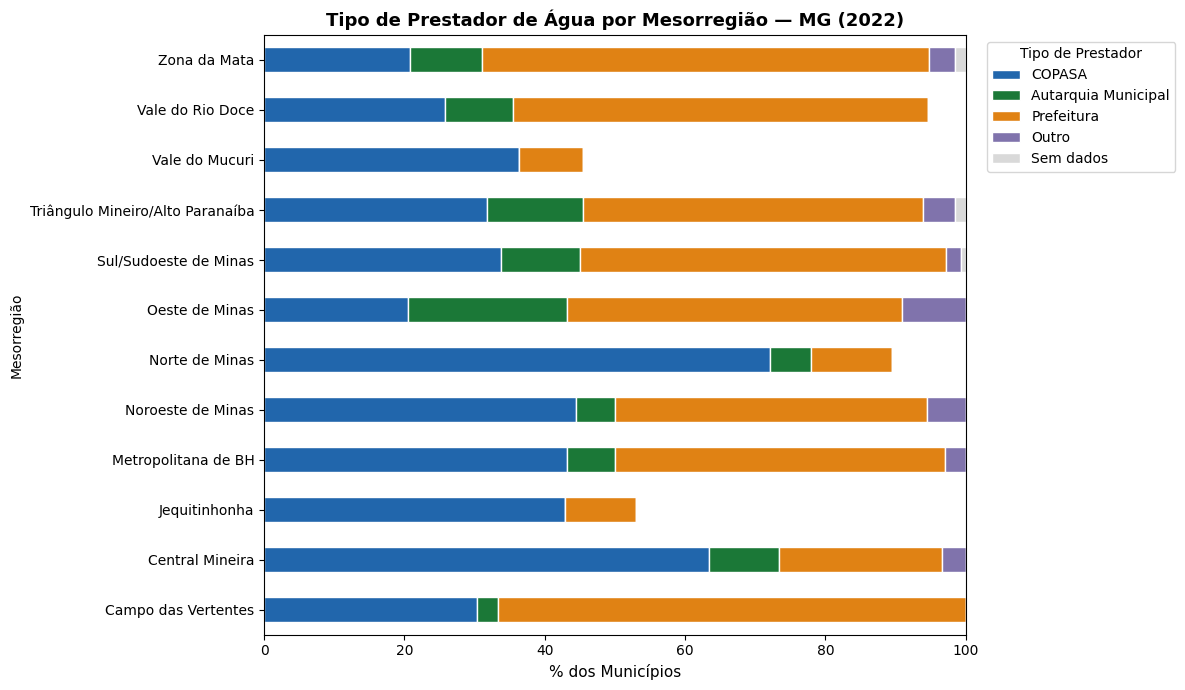

In [26]:
# ── Gráfico empilhado: composição de prestadores por mesorregião ─────────
cross_pct = pd.crosstab(df_meso['Mesorregião'], df_meso['Tipo_Prestador'], normalize='index') * 100
cross_pct = cross_pct.reindex(columns=['COPASA', 'Autarquia Municipal', 'Prefeitura', 'Outro', 'Sem dados'],
                                fill_value=0)

fig, ax = plt.subplots(figsize=(12, 7))
cross_pct.plot(kind='barh', stacked=True, ax=ax,
               color=[cores_tipo.get(c, '#999999') for c in cross_pct.columns],
               edgecolor='white')
ax.set_xlabel('% dos Municípios', fontsize=11)
ax.set_title('Tipo de Prestador de Água por Mesorregião — MG (2022)',
             fontsize=13, fontweight='bold')
ax.legend(title='Tipo de Prestador', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 7. Cobertura Média por Mesorregião

Qual mesorregião tem a melhor e a pior cobertura de água?

In [27]:
# ── Resumo por mesorregião ──────────────────────────────────────────────
resumo_meso = df_meso.groupby('Mesorregião').agg(
    n_municipios=('Município', 'count'),
    cobertura_media=(col_cobertura, 'mean'),
    cobertura_min=(col_cobertura, 'min'),
    perdas_media=(col_perdas, 'mean'),
    pop_total=('POP_TOT - População total do município (Fonte: IBGE):', 'sum')
).round(2).sort_values('cobertura_media')

print('=== Cobertura e Perdas por Mesorregião (ordenado por cobertura) ===\n')
resumo_meso

=== Cobertura e Perdas por Mesorregião (ordenado por cobertura) ===



,n_municipios,cobertura_media,cobertura_min,perdas_media,pop_total
Mesorregião,,,,,
Norte de Minas,86,57.90,17.49,24.41,1631141
Vale do Mucuri,22,59.97,26.53,33.76,360153
Vale do Rio Doce,93,65.81,19.56,29.39,1555469
Zona da Mata,135,67.02,27.08,28.20,2071095
Jequitinhonha,49,67.73,32.67,26.10,651832
Campo das Vertentes,33,72.73,44.91,24.72,476092
Metropolitana de BH,102,74.08,26.18,34.28,6549923
Sul/Sudoeste de Minas,142,74.10,25.72,24.29,2541150
Noroeste de Minas,18,74.57,49.67,22.52,386071


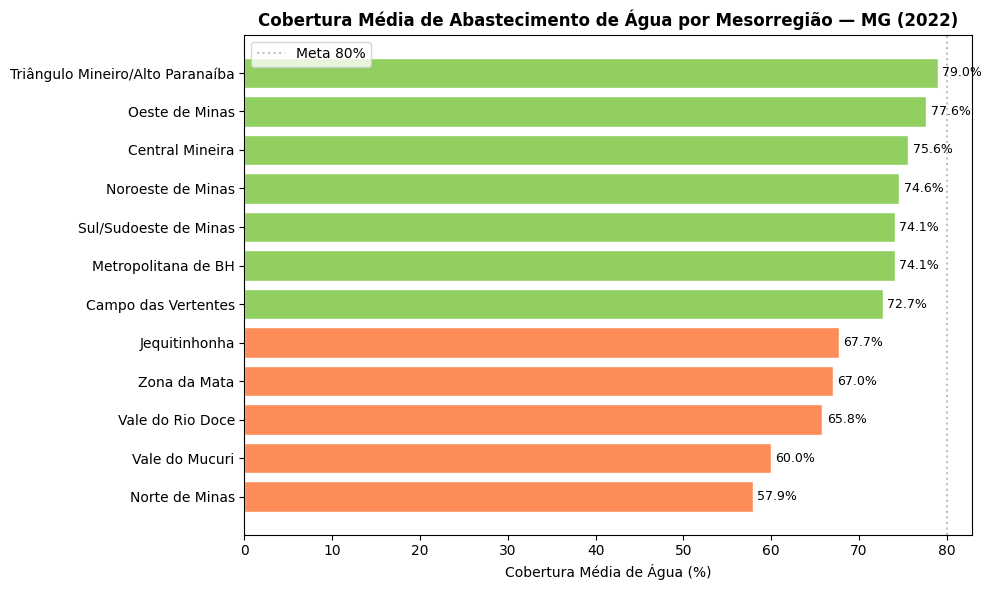

In [28]:
# ── Gráfico: cobertura média por mesorregião ─────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
cores = ['#d73027' if v < 50 else '#fc8d59' if v < 70 else '#91cf60' if v < 85 else '#1a9850'
         for v in resumo_meso['cobertura_media']]
bars = ax.barh(resumo_meso.index, resumo_meso['cobertura_media'],
               color=cores, edgecolor='white')
for bar, val in zip(bars, resumo_meso['cobertura_media']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
ax.set_xlabel('Cobertura Média de Água (%)')
ax.set_title('Cobertura Média de Abastecimento de Água por Mesorregião — MG (2022)',
             fontsize=12, fontweight='bold')
ax.axvline(80, color='gray', ls=':', alpha=0.5, label='Meta 80%')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Conclusões

### Limitações
- Os dados do SNIS são em nível **municipal** — não é possível identificar
  pontos de distribuição específicos (reservatórios, zonas de pressão, redes) dentro de cada município.
- Para uma "planta de distribuição" com pontos de coleta, é necessário
  consultar o **prestador local** (COPASA, SAAE, etc.) ou o cadastro do **Sisagua**.

### O que os dados mostram
- O **prestador principal** de cada município é identificável (COPASA atende a maioria).
- A **cobertura de atendimento** (IN055_AE) varia significativamente entre mesorregiões.
- As **perdas na distribuição** (IN049_AE) indicam a eficiência da rede de cada prestador.
- Mesorregiões do **Norte/Jequitinhonha/Vale do Mucuri** tendem a ter menor cobertura.

### Recomendação (conforme Diretriz Nacional)
- Para obter a planta de distribuição e pontos de coleta, deve-se solicitar ao
  prestador responsável:
  - Planta do sistema de abastecimento (captação, ETA, reservatórios, rede)
  - Zonas de pressão e pontas de rede
  - Cadastro no Sisagua com pontos de monitoramento georreferenciados